# Detector database study

In [2]:
import os, glob, sqlite3, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from Dpipe.load_ptod import DpipeTODCuts

DB    = '/data/users/class/dpipe_db/w1_templates_20260203.db'
DTOD  = '/data/users/class/mapmaking_in/dtod/w1_band/56lp'      #demod version
ADCSV = '/home/carolcyy/moby/Dpipe/data/ArrayData/w1_band/current/array_data.csv'
CACHE = '/tmp/2f_cut_study_meta.npz'
NDET  = 616

# calibrated per-segment 2f metric used by the cuts = |amplitude * scaling_factor|
# the 4 ModTemplate cut files:
F2F = ['ModTemplateLowMedian_0.01045', 'ModTemplateHighVariance_4e-05',
       'ModTemplateAmplitudeOutlier_1.5', 'ModTemplateQualityAmpConditionCut_Q0.95_A0.005']
SHORT = ['LowMedian', 'HighVariance', 'AmpOutlier', 'QualAmpCond']
CCOL  = ['C0', 'C1', 'C2', 'C3']
MINMED, MINBASE, QTHR = 0.01045, 0.01, 0.95     # LowMedian thr / pre-filter amp / quality

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from datetime import datetime as dt
import sqlite3
import importlib
from scipy.ndimage import gaussian_filter1d

from Dpipe import repkg, plt_tools as ptools
from Dpipe.database_utils import check_database_stats

# Import our local analysis helper functions

import w1_band_template_analysis as qta

from pathlib import Path
import sys
sys.path.append(str(Path("../class_code/Dpipe/examples").resolve()))
import cm_daily_template as cm_daily


importlib.reload(qta)
importlib.reload(cm_daily)

<module 'cm_daily_template' from '/home/viviantao1/class_code/Dpipe/examples/cm_daily_template.py'>

In [8]:
print("W1 HWP Template Database Statistics:")
print("=" * 60)
check_database_stats(DB)
print("=" * 60)

W1 HWP Template Database Statistics:
Database: w1_templates_20260203.db
Location: /data/users/class/dpipe_db/w1_templates_20260203.db
Tables: config_info, spans, segments, templates, common_mode

Configuration version: 52lp
Database created: 2026-02-03T14:37:57.134740

Total spans: 290
Boresight distribution:
  -45°:   42 spans
  -30°:   42 spans
  -15°:   40 spans
    0°:   35 spans
   15°:   42 spans
   30°:   45 spans
   45°:   44 spans

Total time segments: 86606
Time range: 2024-07-01 to 2025-08-29
Duration: 423.6 days
Modulator types:
  hwp: 86606
PWV data available: 77131 segments
  Range: 0.06 - 5.22 mm
  Average: 1.20 mm

Total templates: 28175024
Unique detectors: 345
Template quality (R²) by modulator type:
  HWP:
    Count: 28175024
    Average: 0.964
    Range: -94.078 - 1.000
    High quality (≥0.95): 95.7%
Physical amplitudes by modulator type:
  HWP:
    Average: 0.0156
    Range: -2.5118 - 1.1388


In [9]:
array_data = repkg.default_array_data('w1_band', dt(2024, 7, 1), 
                                      fname='array_data')

print(f"Loaded array data with {len(array_data)} detectors")

Loaded array data with 616 detectors


In [10]:
# Get all unique detector UIDs in the database
all_uids = qta.get_unique_detector_uids(DB)

print(f"Total detectors in database: {len(all_uids)}")
print(f"\nExample UIDs: {all_uids[:10]}")

Total detectors in database: 345

Example UIDs: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10]


In [7]:
print(max(all_uids))

615


In [11]:
# Query all high-quality templates
# Quality threshold of 0.5 means R² >= 0.5 (good sine fit)
quality_threshold = 0.5
data = qta.query_database(DB, quality_threshold=quality_threshold)

n_dets, n_times = data['amplitudes'].shape
n_valid = np.sum(~np.isnan(data['amplitudes']))
print(f"Retrieved {n_dets} detectors × {n_times} times ({n_valid} valid measurements) with quality >= {quality_threshold}")
print(f"Time range: {dt.fromtimestamp(data['timestamps'].min())} to {dt.fromtimestamp(data['timestamps'].max())}")
print(data.keys())

Retrieved 345 detectors × 82426 times (25813650 valid measurements) with quality >= 0.5
Time range: 2024-07-01 21:29:59.130019 to 2025-08-29 11:07:29.289533
dict_keys(['amplitudes', 'amplitude_errors', 'phases', 'phase_errors', 'quality', 'scaling_factors', 'original_amplitudes', 'timestamps', 'det_uids', 'spans', 'span_paths', 'boresights', 'elevations', 'pwv', 'mod_freq', 'modulator_type', 'subdivision_index'])


In [12]:
stats = qta.compute_detector_statistics(data)
# Compute statistics for each detector
print(f"Computed statistics for {len(stats)} detectors\n")

# Show example for a few detectors
example_uids = list(stats.keys())[:5]
for uid in example_uids:
    s = stats[uid]
    print(f"UID {uid:3d}: median_amp={s['median_amplitude']:.4f}, "
          f"σ={s['std_amplitude']:.4f}, n={s['n_samples']}, "
          f"quality={s['median_quality']:.3f}")

Computed statistics for 345 detectors

UID   0: median_amp=0.0155, σ=0.0018, n=81509, quality=1.000
UID   1: median_amp=0.0192, σ=0.0017, n=81834, quality=1.000
UID   2: median_amp=0.0150, σ=0.0021, n=10666, quality=1.000
UID   3: median_amp=0.0155, σ=0.0016, n=70040, quality=1.000
UID   4: median_amp=0.0165, σ=0.0017, n=80602, quality=1.000


In [13]:
db_rows = [stats[det] for det in all_uids]
df_stats = pd.DataFrame(db_rows, index=all_uids)
df_stats

,median_amplitude,std_amplitude,var_amplitude,n_samples,median_quality,median_pwv
0,0.015499,0.001813,0.000003,81509,0.999997,0.94
1,0.019157,0.001718,0.000003,81834,0.999998,0.94
2,0.015011,0.002075,0.000004,10666,0.999996,1.11
3,0.015453,0.001610,0.000003,70040,0.999997,0.93
4,0.016521,0.001684,0.000003,80602,0.999997,0.94
...,...,...,...,...,...,...
609,0.023642,0.004165,0.000017,82188,0.999999,0.94
612,0.023457,0.004089,0.000017,82297,0.999999,0.94
613,0.024154,0.003749,0.000014,81971,0.999999,0.94
614,0.024697,0.004041,0.000016,82130,0.999999,0.94


(array([104.,  76.,  71.,  36.,  21.,  19.,   9.,   6.,   1.,   2.]),
 array([1.84723741e-06, 7.87549927e-06, 1.39037611e-05, 1.99320230e-05,
        2.59602849e-05, 3.19885467e-05, 3.80168086e-05, 4.40450704e-05,
        5.00733323e-05, 5.61015942e-05, 6.21298560e-05]),
 <BarContainer object of 10 artists>)

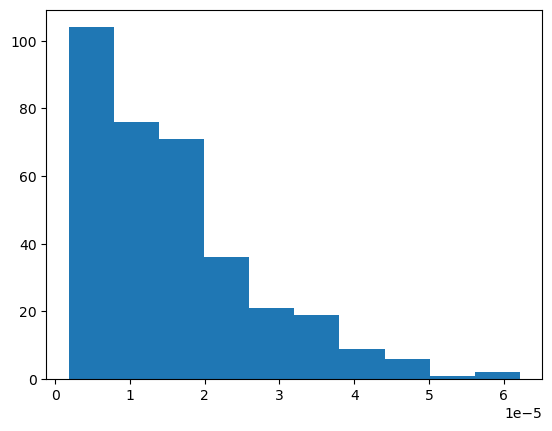

In [9]:
plt.hist(df_stats['var_amplitude'])

In [14]:
array_data = pd.read_csv(ADCSV)
#array_data.set_index('det_uid', inplace=True)
array_data

,det_uid,feedhorn,type,col,row,bias,wafer,module,detnum,file_name,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual
0,0,1,V,3,0,1,W7,0,1,mcew1_filt_r00c03,-0.020466,-0.096745,-45.0,1.1427,167.94,27906.70,11.49,NaN
1,1,1,H,3,1,1,W7,0,1,mcew1_filt_r01c03,-0.020469,-0.096837,45.0,0.9438,0.00,0.00,0.00,NaN
2,2,5,H,3,2,1,W7,0,5,mcew1_filt_r02c03,-0.039629,-0.085935,45.0,1.1734,167.72,27737.33,10.81,NaN
3,3,5,V,3,3,1,W7,0,5,mcew1_filt_r03c03,-0.039595,-0.085903,-45.0,1.1624,168.52,22579.07,12.92,NaN
4,4,11,H,3,4,1,W7,0,11,mcew1_filt_r04c03,-0.059351,-0.095703,45.0,1.1692,163.22,26447.96,11.49,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,611,0,DS,30,4,7,W2-1,5,DS,mcew1_filt_r04c30,-0.105428,0.180403,NaN,-1.0000,0.00,0.00,0.00,NaN
612,612,194,H,30,3,7,W2-1,5,9,mcew1_filt_r03c30,-0.105432,0.180265,45.0,1.1620,170.45,16704.23,13.43,NaN
613,613,194,V,30,2,7,W2-1,5,9,mcew1_filt_r02c30,-0.105428,0.180581,-45.0,1.1290,179.11,16293.25,13.24,NaN
614,614,189,V,30,1,7,W2-1,5,4,mcew1_filt_r01c30,-0.123198,0.171624,-45.0,1.2218,182.92,7747.06,13.36,NaN


In [15]:
df = pd.merge(df_stats, array_data, left_index=True, right_index=True, how='left')
#df.index.name = 'det_uid'
# df.to_csv("detector_stats.csv", index=False)
df

,median_amplitude,std_amplitude,var_amplitude,n_samples,median_quality,median_pwv,det_uid,feedhorn,type,col,...,detnum,file_name,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual
0,0.015499,0.001813,0.000003,81509,0.999997,0.94,0,1,V,3,...,1,mcew1_filt_r00c03,-0.020466,-0.096745,-45.0,1.1427,167.94,27906.70,11.49,NaN
1,0.019157,0.001718,0.000003,81834,0.999998,0.94,1,1,H,3,...,1,mcew1_filt_r01c03,-0.020469,-0.096837,45.0,0.9438,0.00,0.00,0.00,NaN
2,0.015011,0.002075,0.000004,10666,0.999996,1.11,2,5,H,3,...,5,mcew1_filt_r02c03,-0.039629,-0.085935,45.0,1.1734,167.72,27737.33,10.81,NaN
3,0.015453,0.001610,0.000003,70040,0.999997,0.93,3,5,V,3,...,5,mcew1_filt_r03c03,-0.039595,-0.085903,-45.0,1.1624,168.52,22579.07,12.92,NaN
4,0.016521,0.001684,0.000003,80602,0.999997,0.94,4,11,H,3,...,11,mcew1_filt_r04c03,-0.059351,-0.095703,45.0,1.1692,163.22,26447.96,11.49,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.023642,0.004165,0.000017,82188,0.999999,0.94,609,199,H,30,...,14,mcew1_filt_r06c30,-0.088497,0.168313,45.0,1.1939,163.51,15642.45,12.67,NaN
612,0.023457,0.004089,0.000017,82297,0.999999,0.94,612,194,H,30,...,9,mcew1_filt_r03c30,-0.105432,0.180265,45.0,1.1620,170.45,16704.23,13.43,NaN
613,0.024154,0.003749,0.000014,81971,0.999999,0.94,613,194,V,30,...,9,mcew1_filt_r02c30,-0.105428,0.180581,-45.0,1.1290,179.11,16293.25,13.24,NaN
614,0.024697,0.004041,0.000016,82130,0.999999,0.94,614,189,V,30,...,4,mcew1_filt_r01c30,-0.123198,0.171624,-45.0,1.2218,182.92,7747.06,13.36,NaN


In [16]:
amp_cors = df.corr(numeric_only=True)['median_amplitude'].drop(['median_amplitude', 'std_amplitude', 'var_amplitude', 'n_samples', 'median_quality'])
std_cors = df.corr(numeric_only=True)['std_amplitude'].drop(['median_amplitude', 'std_amplitude', 'var_amplitude', 'n_samples', 'median_quality'])
n_cors = df.corr(numeric_only=True)['n_samples'].drop(['median_amplitude', 'std_amplitude', 'var_amplitude', 'n_samples', 'median_quality'])
quality_cors = df.corr(numeric_only=True)['median_quality'].drop(['median_amplitude', 'std_amplitude', 'var_amplitude', 'n_samples', 'median_quality'])

correlation_matrix = pd.DataFrame({
    'median_amplitude': amp_cors,
    'std_amplitude': std_cors,
    'n_samples': n_cors,
    'median_quality': quality_cors
})

correlation_matrix

,median_amplitude,std_amplitude,n_samples,median_quality
median_pwv,0.018551,0.101115,-0.591845,0.021584
det_uid,0.519168,0.561682,-0.153407,0.138846
feedhorn,0.508010,0.432768,0.056248,0.140898
col,0.529550,0.568220,-0.192120,0.144989
row,-0.154599,0.202110,0.180660,-0.014801
bias,0.522796,0.570555,-0.182832,0.134522
module,0.525153,0.404623,0.035266,0.128372
az_off,0.019611,-0.181533,0.332791,0.031969
el_off,0.587399,0.480506,-0.078225,0.096871
rot,-0.067631,0.020577,-0.051346,-0.004091


In [17]:
detector_sort = np.load("detector_sort.npz")
bad_detectors = detector_sort['bad_detectors']
good_detectors = detector_sort['good_detectors']
ok_detectors = detector_sort['ok_detectors']
pair_counts = detector_sort['pair_counts']

# var = np.load("avg_span_var_per_det.npz")
# span_var = var['arr_0']


In [14]:
array_data[(array_data['wafer']=='W3')]

,feedhorn,type,col,row,bias,wafer,module,detnum,file_name,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual
det_uid,,,,,,,,,,,,,,,,,
352,75,V,23,0,5,W3,2,1,mcew1_filt_r00c23,-0.094343,0.037039,NaN,-1.0000,186.99,19598.30,12.24,NaN
353,75,H,23,1,5,W3,2,1,mcew1_filt_r01c23,-0.094312,0.037016,45.0,1.0904,0.00,0.00,0.00,NaN
354,79,H,23,2,5,W3,2,5,mcew1_filt_r02c23,-0.112338,0.049863,NaN,-1.0000,184.93,21532.87,11.99,NaN
355,79,V,23,3,5,W3,2,5,mcew1_filt_r03c23,-0.112210,0.049719,-45.0,1.4088,195.46,13211.44,9.94,NaN
356,85,H,23,4,5,W3,2,11,mcew1_filt_r04c23,-0.130986,0.040514,45.0,0.9019,175.76,24614.95,13.75,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0,DS,22,4,5,W3,2,DS,mcew1_filt_r04c22,NaN,NaN,NaN,-1.0000,0.00,0.00,0.00,NaN
436,83,H,22,3,5,W3,2,9,mcew1_filt_r03c22,-0.115601,-0.036342,45.0,0.6593,186.25,18023.32,11.34,NaN
437,83,V,22,2,5,W3,2,9,mcew1_filt_r02c22,-0.115616,-0.036386,NaN,-1.0000,0.00,0.00,0.00,NaN


In [18]:
df['performance'] = "ok"
df.loc[df.index.isin(good_detectors), "performance"] = "good"
df.loc[df.index.isin(bad_detectors), "performance"] = "bad"
df['surviving_spans'] = pair_counts
df['az_off'] = np.degrees(df['az_off'])
df['el_off'] = np.degrees(df['el_off'])
# df['span_var_avg'] = span_var
df.to_csv("detector_stats.csv", index=False)
df

,median_amplitude,std_amplitude,var_amplitude,n_samples,median_quality,median_pwv,det_uid,feedhorn,type,col,...,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual,performance,surviving_spans
0,0.015499,0.001813,0.000003,81509,0.999997,0.94,0,1,V,3,...,-1.172615,-5.543080,-45.0,1.1427,167.94,27906.70,11.49,NaN,good,284
1,0.019157,0.001718,0.000003,81834,0.999998,0.94,1,1,H,3,...,-1.172787,-5.548351,45.0,0.9438,0.00,0.00,0.00,NaN,good,284
2,0.015011,0.002075,0.000004,10666,0.999996,1.11,2,5,H,3,...,-2.270574,-4.923713,45.0,1.1734,167.72,27737.33,10.81,NaN,good,250
3,0.015453,0.001610,0.000003,70040,0.999997,0.93,3,5,V,3,...,-2.268626,-4.921879,-45.0,1.1624,168.52,22579.07,12.92,NaN,good,267
4,0.016521,0.001684,0.000003,80602,0.999997,0.94,4,11,H,3,...,-3.400562,-5.483378,45.0,1.1692,163.22,26447.96,11.49,NaN,good,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.023642,0.004165,0.000017,82188,0.999999,0.94,609,199,H,30,...,-5.070505,9.643625,45.0,1.1939,163.51,15642.45,12.67,NaN,good,243
612,0.023457,0.004089,0.000017,82297,0.999999,0.94,612,194,H,30,...,-6.040809,10.328424,45.0,1.1620,170.45,16704.23,13.43,NaN,good,254
613,0.024154,0.003749,0.000014,81971,0.999999,0.94,613,194,V,30,...,-6.040579,10.346529,-45.0,1.1290,179.11,16293.25,13.24,NaN,good,263
614,0.024697,0.004041,0.000016,82130,0.999999,0.94,614,189,V,30,...,-7.058725,9.833331,-45.0,1.2218,182.92,7747.06,13.36,NaN,good,264


In [4]:
df = pd.read_csv("detector_stats.csv", index_col='det_uid')
#df.set_index('det_uid')
df

,median_amplitude,std_amplitude,var_amplitude,n_samples,median_quality,median_pwv,feedhorn,type,col,row,...,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual,performance,surviving_spans
det_uid,,,,,,,,,,,,,,,,,,,,,
0,0.015499,0.001813,0.000003,81509,0.999997,0.94,1,V,3,0,...,-1.172615,-5.543080,-45.0,1.1427,167.94,27906.70,11.49,NaN,good,284
1,0.019157,0.001718,0.000003,81834,0.999998,0.94,1,H,3,1,...,-1.172787,-5.548351,45.0,0.9438,0.00,0.00,0.00,NaN,good,284
2,0.015011,0.002075,0.000004,10666,0.999996,1.11,5,H,3,2,...,-2.270574,-4.923713,45.0,1.1734,167.72,27737.33,10.81,NaN,good,250
3,0.015453,0.001610,0.000003,70040,0.999997,0.93,5,V,3,3,...,-2.268626,-4.921879,-45.0,1.1624,168.52,22579.07,12.92,NaN,good,267
4,0.016521,0.001684,0.000003,80602,0.999997,0.94,11,H,3,4,...,-3.400562,-5.483378,45.0,1.1692,163.22,26447.96,11.49,NaN,good,276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.023642,0.004165,0.000017,82188,0.999999,0.94,199,H,30,6,...,-5.070505,9.643625,45.0,1.1939,163.51,15642.45,12.67,NaN,good,243
612,0.023457,0.004089,0.000017,82297,0.999999,0.94,194,H,30,3,...,-6.040809,10.328424,45.0,1.1620,170.45,16704.23,13.43,NaN,good,254
613,0.024154,0.003749,0.000014,81971,0.999999,0.94,194,V,30,2,...,-6.040579,10.346529,-45.0,1.1290,179.11,16293.25,13.24,NaN,good,263


In [5]:
base = df[['wafer', 'module', 'bias', 'feedhorn', 'performance', 'col', 'median_amplitude', 'std_amplitude', 'var_amplitude']]
high_amp_bad = base[(base['performance'] == 'bad') & (base['median_amplitude'] > 0.01)]
high_amp_bad

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
161,W2-3,1,2,70,bad,6,0.010451,0.004834,0.000023
281,W2-2,3,4,146,bad,19,0.011757,0.005236,0.000027
331,W2-2,3,4,147,bad,18,0.011760,0.005236,0.000027
359,W3,2,5,84,bad,23,0.016299,0.004027,0.000016
443,W6,6,6,227,bad,27,0.018876,0.003982,0.000016


In [25]:
high_amp_ok = base[(base['performance'] == 'ok') & (base['median_amplitude'] > 0.01)]
high_amp_ok

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
8,W7,0,1,10,ok,3,0.015979,0.003487,0.000012
45,W7,0,1,19,ok,0,0.015124,0.003115,0.000010
47,W7,0,1,7,ok,0,0.016124,0.002566,0.000007
89,W2-3,1,2,38,ok,7,0.012061,0.004776,0.000023
90,W2-3,1,2,42,ok,7,0.014075,0.002868,0.000008
...,...,...,...,...,...,...,...,...,...
516,W6,6,6,244,ok,26,0.015615,0.005714,0.000033
517,W6,6,6,244,ok,26,0.015894,0.006097,0.000037
520,W6,6,6,237,ok,26,0.017357,0.006425,0.000041


In [22]:
high_var = base[base['var_amplitude']>3e-5]
high_var

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
30,W7,0,1,12,bad,1,0.000041,0.005848,0.000034
110,W2-3,1,2,61,ok,5,0.011730,0.005672,0.000032
154,W2-3,1,2,69,bad,6,0.006753,0.005627,0.000032
225,W2-4,4,3,151,ok,12,0.016841,0.006992,0.000049
243,W2-4,4,3,184,ok,14,0.020630,0.007330,0.000054
280,W2-2,3,4,145,bad,19,0.002627,0.006488,0.000042
282,W2-2,3,4,146,ok,19,0.015633,0.006003,0.000036
287,W2-2,3,4,135,bad,17,0.000307,0.005658,0.000032
289,W2-2,3,4,128,ok,17,0.016045,0.006545,0.000043


In [23]:
high_var_good = high_var[high_var['performance']=='good']
high_var_good

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
382,W3,2,5,86,good,21,0.021518,0.005573,0.000031
392,W3,2,5,105,good,21,0.023437,0.005522,0.000030
393,W3,2,5,100,good,21,0.020799,0.006534,0.000043
396,W3,2,5,93,good,20,0.020534,0.006552,0.000043
511,W6,6,6,259,good,26,0.020851,0.005979,0.000036
524,W6,6,6,231,good,26,0.020462,0.006061,0.000037
525,W6,6,6,226,good,26,0.020373,0.005695,0.000032
615,W2-1,5,7,189,good,30,0.025054,0.005671,0.000032


In [24]:
low_amp_bad = base[(base['performance']=='bad')&(base['median_amplitude'] <= 0.01)]
low_amp_bad

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
7,W7,0,1,10,bad,3,0.006831,0.002977,0.000009
30,W7,0,1,12,bad,1,0.000041,0.005848,0.000034
32,W7,0,1,6,bad,1,0.000039,0.002877,0.000008
33,W7,0,1,6,bad,1,0.000008,0.002712,0.000007
103,W2-3,1,2,71,bad,7,0.002977,0.003832,0.000015
106,W2-3,1,2,72,bad,7,0.001034,0.003292,0.000011
154,W2-3,1,2,69,bad,6,0.006753,0.005627,0.000032
158,W2-3,1,2,74,bad,6,0.005860,0.004320,0.000019
159,W2-3,1,2,74,bad,6,0.005271,0.004122,0.000017


In [22]:
low_amp = base[(base['median_amplitude'] <= 0.01)]
low_amp

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
7,W7,0,1,10,bad,3,0.006831,0.002977,0.000009
30,W7,0,1,12,bad,1,0.000041,0.005848,0.000034
32,W7,0,1,6,bad,1,0.000039,0.002877,0.000008
33,W7,0,1,6,bad,1,0.000008,0.002712,0.000007
103,W2-3,1,2,71,bad,7,0.002977,0.003832,0.000015
106,W2-3,1,2,72,bad,7,0.001034,0.003292,0.000011
154,W2-3,1,2,69,bad,6,0.006753,0.005627,0.000032
158,W2-3,1,2,74,bad,6,0.005860,0.004320,0.000019
159,W2-3,1,2,74,bad,6,0.005271,0.004122,0.000017


In [26]:
col23 = base[base['col']==23]
col23

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
353,W3,2,5,75,ok,23,0.013866,0.001741,0.000003
355,W3,2,5,79,ok,23,0.012899,0.001705,0.000003
356,W3,2,5,85,ok,23,0.021196,0.003668,0.000013
358,W3,2,5,85,ok,23,0.016356,0.003324,0.000011
359,W3,2,5,84,bad,23,0.016299,0.004027,0.000016
360,W3,2,5,84,ok,23,0.017171,0.003955,0.000016
361,W3,2,5,90,ok,23,0.022835,0.003932,0.000015
362,W3,2,5,90,ok,23,0.023910,0.004092,0.000017
363,W3,2,5,97,ok,23,0.022734,0.004997,0.000025


In [27]:
col30 = base[base['col']==30]
col30

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
595,W2-1,5,7,221,good,30,0.020492,0.004559,0.000021
596,W2-1,5,7,221,good,30,0.020791,0.004733,0.000022
598,W2-1,5,7,222,good,30,0.021174,0.005082,0.000026
604,W2-1,5,7,207,good,30,0.021906,0.004630,0.000021
605,W2-1,5,7,207,good,30,0.022551,0.004568,0.000021
607,W2-1,5,7,200,good,30,0.022917,0.004114,0.000017
608,W2-1,5,7,200,good,30,0.023371,0.004384,0.000019
609,W2-1,5,7,199,good,30,0.023642,0.004165,0.000017
612,W2-1,5,7,194,good,30,0.023457,0.004089,0.000017


In [35]:
base[base['feedhorn']==7]


,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
47,W7,0,1,7,ok,0,0.016124,0.002566,0.000007
48,W7,0,1,7,good,0,0.014841,0.002190,0.000005


## Array

In [132]:
plus45_det = df[df['rot']==45]
minus45_det = df[df['rot']==-45]
plus45_det

,median_amplitude,std_amplitude,var_amplitude,n_samples,median_quality,median_pwv,feedhorn,type,col,row,...,az_off,el_off,rot,eff_rel,Tc,kappa,Rn,det_qual,performance,surviving_spans
det_uid,,,,,,,,,,,,,,,,,,,,,
1,0.019157,0.001718,0.000003,81834,0.999998,0.94,1,H,3,1,...,-1.172787,-5.548351,45.0,0.9438,0.00,0.00,0.00,NaN,good,284
2,0.015011,0.002075,0.000004,10666,0.999996,1.11,5,H,3,2,...,-2.270574,-4.923713,45.0,1.1734,167.72,27737.33,10.81,NaN,good,250
4,0.016521,0.001684,0.000003,80602,0.999997,0.94,11,H,3,4,...,-3.400562,-5.483378,45.0,1.1692,163.22,26447.96,11.49,NaN,good,276
8,0.015979,0.003487,0.000012,82294,0.999997,0.94,10,H,3,8,...,-3.362346,-4.274380,45.0,0.7525,136.07,29653.00,9.39,NaN,ok,221
9,0.017387,0.001600,0.000003,81938,0.999998,0.94,16,H,3,9,...,-4.443345,-3.615020,45.0,1.1146,160.05,25747.10,10.78,NaN,good,285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,0.021906,0.004630,0.000021,82329,0.999999,0.94,207,H,30,11,...,-3.994834,11.405069,45.0,1.1259,162.68,15693.51,13.42,NaN,good,254
608,0.023371,0.004384,0.000019,82160,0.999999,0.94,200,H,30,7,...,-5.013839,10.863566,45.0,1.1013,169.50,15997.60,12.94,NaN,good,245
609,0.023642,0.004165,0.000017,82188,0.999999,0.94,199,H,30,6,...,-5.070505,9.643625,45.0,1.1939,163.51,15642.45,12.67,NaN,good,243


Text(0.5, 1.0, 'Median 2f Amplitude')

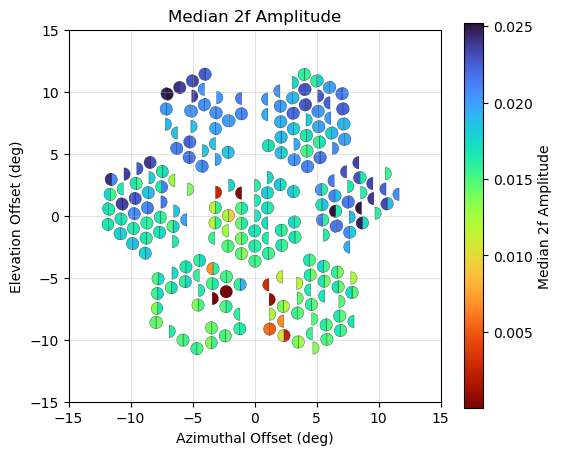

In [134]:
from matplotlib.patches import Wedge
from matplotlib.colors import Normalize
from matplotlib import cm

r = 0.5
cmap = plt.get_cmap("turbo_r")
norm = Normalize(vmin=df["median_amplitude"].min(), vmax=df["median_amplitude"].max())

fig, ax = plt.subplots(figsize=(6, 5))

for _, row in plus45_det.iterrows():
    # print(row['az_off'], row['el_off'])
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor=cmap(norm(row['median_amplitude'])), edgecolor='black', linewidth=0.2))
    
for _, row in minus45_det.iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor=cmap(norm(row['median_amplitude'])), edgecolor='black', linewidth=0.2))

ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Azimuthal Offset (deg)")
ax.set_ylabel("Elevation Offset (deg)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Median 2f Amplitude")
plt.title("Median 2f Amplitude")



Text(0.5, 1.0, '2f Amplitude Variance')

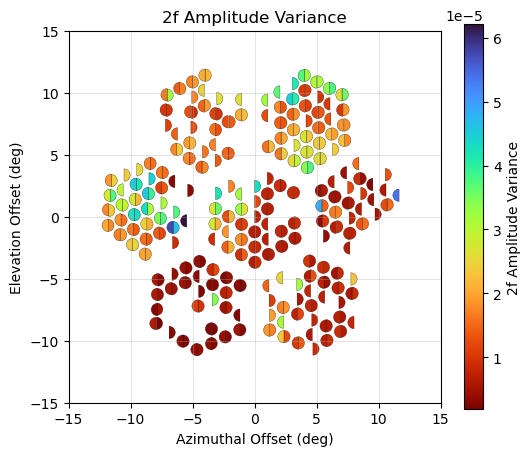

In [135]:
from matplotlib.patches import Wedge
from matplotlib.colors import Normalize
from matplotlib import cm

r = 0.5
cmap = plt.get_cmap("turbo_r")
norm = Normalize(vmin=df["var_amplitude"].min(), vmax=df["var_amplitude"].max())

fig, ax = plt.subplots(figsize=(6, 5))

for _, row in plus45_det.iterrows():
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor=cmap(norm(row['var_amplitude'])), edgecolor='black', linewidth=0.2))
    
for _, row in minus45_det.iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor=cmap(norm(row['var_amplitude'])), edgecolor='black', linewidth=0.2))

ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Azimuthal Offset (deg)")
ax.set_ylabel("Elevation Offset (deg)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="2f Amplitude Variance")
plt.title("2f Amplitude Variance")

Text(0.5, 1.0, 'Number of Surviving Spans per Detector')

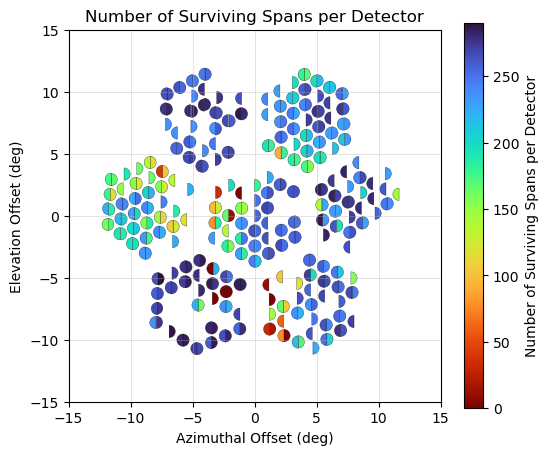

In [136]:
r = 0.5
cmap = plt.get_cmap("turbo_r")
norm = Normalize(vmin=df["surviving_spans"].min(), vmax=df["surviving_spans"].max())

fig, ax = plt.subplots(figsize=(6, 5))

for _, row in plus45_det.iterrows():
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor=cmap(norm(row['surviving_spans'])), edgecolor='black', linewidth=0.2))
    
for _, row in minus45_det.iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor=cmap(norm(row['surviving_spans'])), edgecolor='black', linewidth=0.2))

ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Azimuthal Offset (deg)")
ax.set_ylabel("Elevation Offset (deg)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label="Number of Surviving Spans per Detector")
plt.title("Number of Surviving Spans per Detector")

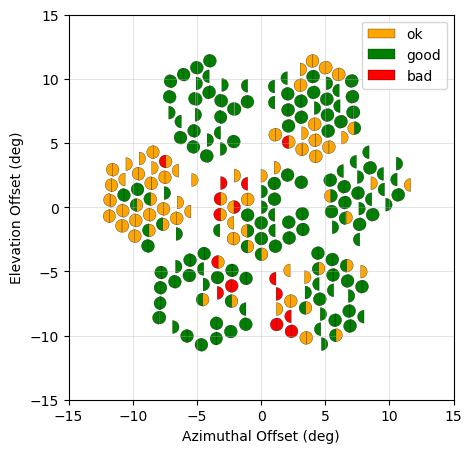

In [137]:
r = 0.5
cmap = plt.get_cmap("turbo_r")
norm = Normalize(vmin=df["surviving_spans"].min(), vmax=df["surviving_spans"].max())

fig, ax = plt.subplots(figsize=(5, 5))

for _, row in plus45_det[plus45_det['performance']=='ok'].iterrows():
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor='orange', edgecolor='black', linewidth=0.2, label='ok'))
    
for _, row in minus45_det[minus45_det['performance']=='ok'].iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor='orange', edgecolor='black', linewidth=0.2))
    
for _, row in plus45_det[plus45_det['performance']=='good'].iterrows():
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor='green', edgecolor='black', linewidth=0.2, label='good'))
    
for _, row in minus45_det[minus45_det['performance']=='good'].iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor='green', edgecolor='black', linewidth=0.2))
    

for _, row in plus45_det[plus45_det['performance']=='bad'].iterrows():
    # Right half (-90° to 90°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, -90, 90,
                    facecolor='red', edgecolor='black', linewidth=0.2, label='bad'))
    
for _, row in minus45_det[minus45_det['performance']=='bad'].iterrows():
    # Left half (90° to 270°)
    ax.add_patch(Wedge((row['az_off'], row['el_off']), r, 90, 270,
                    facecolor='red', edgecolor='black', linewidth=0.2))

ax.set_xlim(-15,15)
ax.set_ylim(-15,15)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Azimuthal Offset (deg)")
ax.set_ylabel("Elevation Offset (deg)")

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# plt.colorbar(sm, ax=ax, label="Number of Surviving Spans per Detector")
#plt.title("Number of Surviving Spans per Detector")
handles, labels = plt.gca().get_legend_handles_labels()

by_label = dict(zip(labels, handles))

plt.legend(by_label.values(), by_label.keys())

## FEEDHORNS:
It appears that from feedhorns 65 to 90, there are no good detectors

Text(0.5, 0.98, 'Feedhorn')

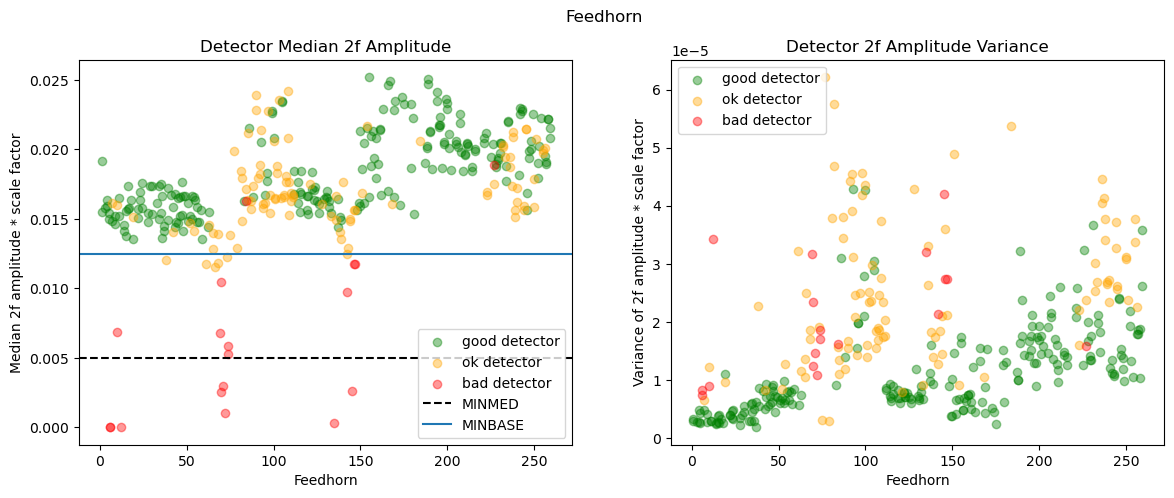

In [71]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['feedhorn'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Feedhorn")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['feedhorn'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Feedhorn")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Feedhorn")


Text(0.5, 0.98, 'Feedhorn')

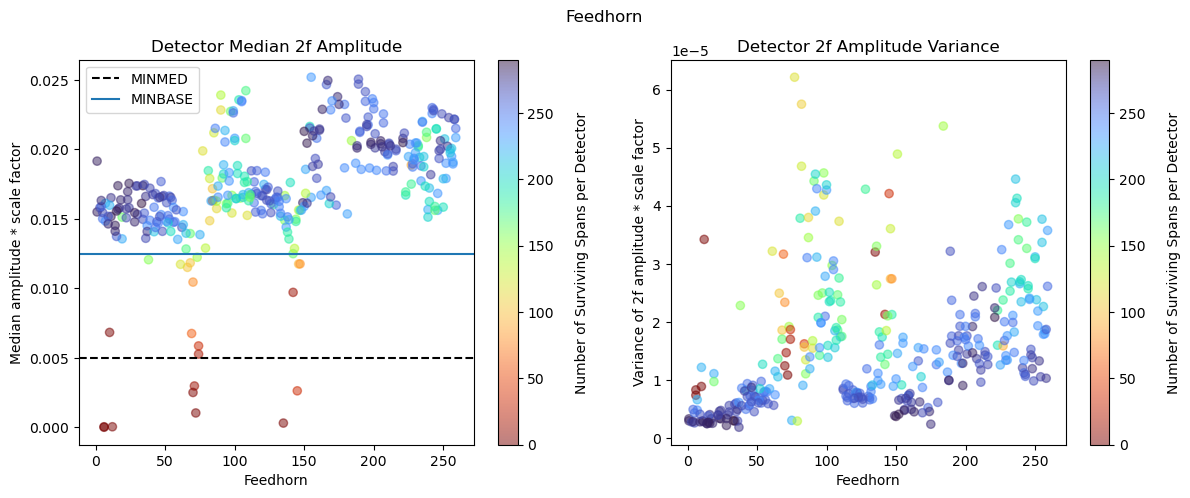

In [72]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['feedhorn'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Feedhorn")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['feedhorn'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Feedhorn")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Feedhorn")

(0.0, 250.0)

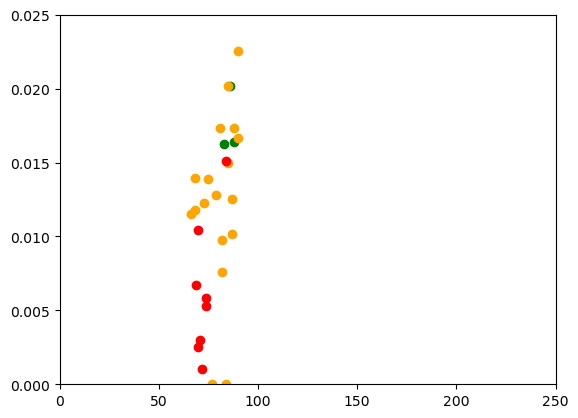

In [24]:
bad_feedhorn = df[(df["feedhorn"]>=66)&(df['feedhorn']<=90)]
color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = bad_feedhorn["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = bad_feedhorn["performance"] == group
    plt.scatter(
        bad_feedhorn['feedhorn'][mask],
        bad_feedhorn['median_amplitude'][mask],
        color=color,
        label=group
    )

plt.ylim(0,0.025)
plt.xlim(0,250)

In [ ]:
b = bad_feedhorn[['wafer', 'module', 'bias', 'feedhorn', 'performance', 'col', 'median_amplitude', 'std_amplitude', 'var_amplitude']]
b = b[(b['performance'] == 'ok') & (b['median_amplitude'] > 0.01)]
b

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude
det_uid,,,,,,,,
102,W2-3,1,2,66,ok,7,0.011508,0.004996
127,W2-3,1,2,68,ok,5,0.011768,0.004557
128,W2-3,1,2,68,ok,5,0.013941,0.004152
156,W2-3,1,2,73,ok,6,0.012238,0.004383
353,W3,2,5,75,ok,23,0.013864,0.001834
355,W3,2,5,79,ok,23,0.012785,0.003739
356,W3,2,5,85,ok,23,0.020156,0.009931
358,W3,2,5,85,ok,23,0.014955,0.013024
361,W3,2,5,90,ok,23,0.016672,0.011054


In [24]:
good_feedhorn = base[base['feedhorn']==200]
good_feedhorn

,wafer,module,bias,feedhorn,performance,col,median_amplitude,std_amplitude,var_amplitude
det_uid,,,,,,,,,
607,W2-1,5,7,200,good,30,0.022917,0.004114,0.000017
608,W2-1,5,7,200,good,30,0.023371,0.004384,0.000019


Text(0.5, 0.98, 'Feedhorn: standard deviation correlation')

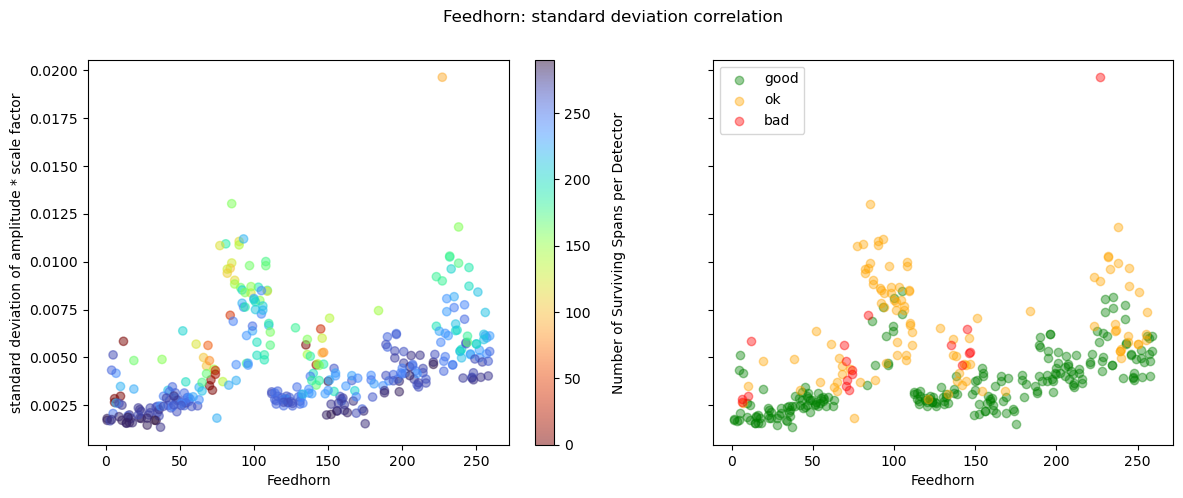

In [28]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [8, 7]}
)

sc = ax1.scatter(df['feedhorn'], df['std_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Feedhorn")
ax1.set_ylabel("standard deviation of amplitude * scale factor")

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['feedhorn'][mask],
        df['std_amplitude'][mask],
        color=color,
        label=group,
        alpha=0.4
    )
ax2.set_xlabel("Feedhorn")
ax2.legend()
fig.suptitle("Feedhorn: standard deviation correlation")

## MODULE

Text(0.5, 0.98, 'Module')

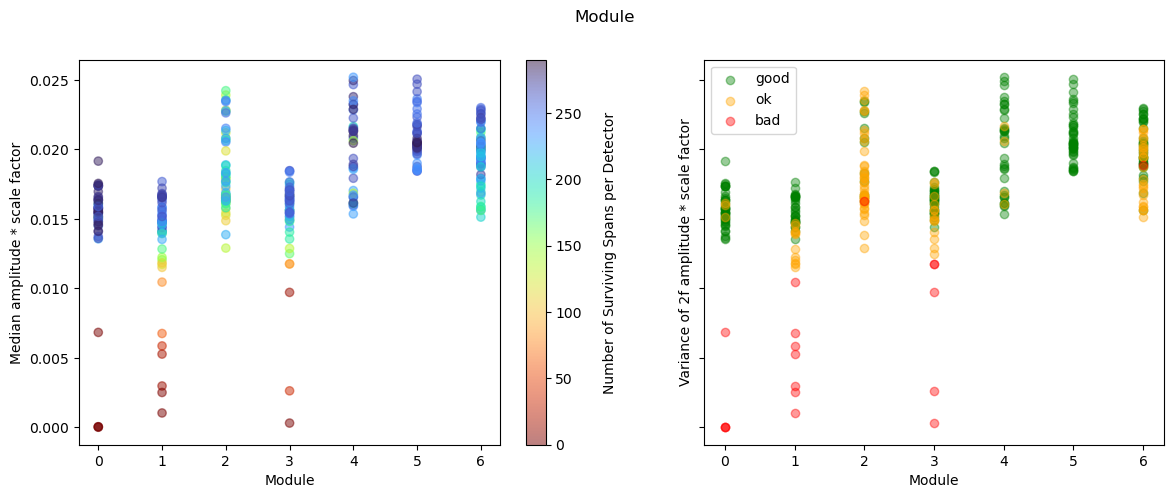

In [74]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [8, 7]}
)

sc = ax1.scatter(df['module'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Module")
ax1.set_ylabel("Median amplitude * scale factor")

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['module'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=group,
        alpha=0.4
    )
ax2.set_xlabel("Module")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.legend()
fig.suptitle("Module")

Text(0.5, 0.98, 'Module')

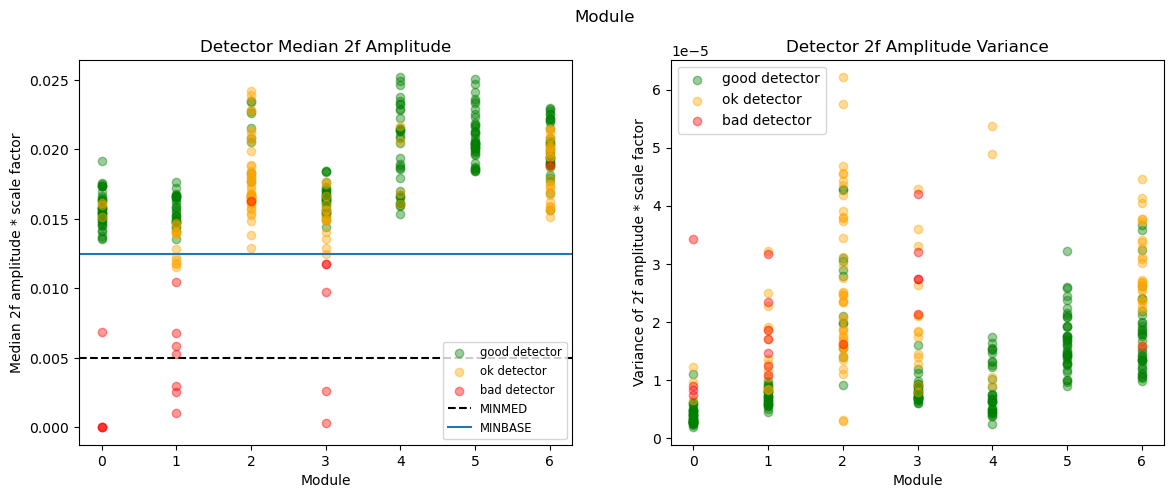

In [73]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['module'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Module")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower right', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['module'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Module")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Module")

Text(0.5, 0.98, 'Module')

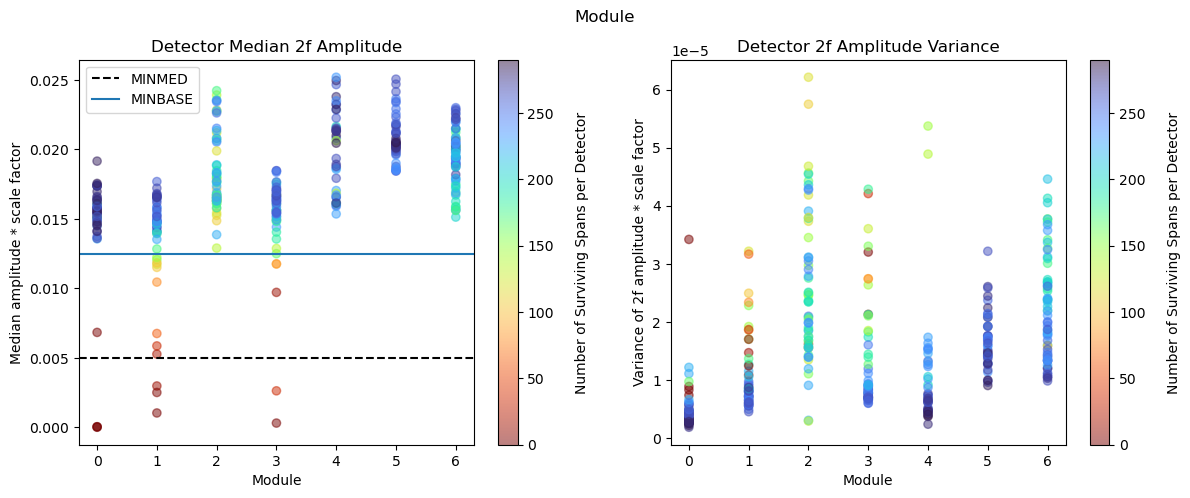

In [75]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['module'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Module")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['module'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Module")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Module")

## BIAS

Text(0.5, 0.98, 'Bias')

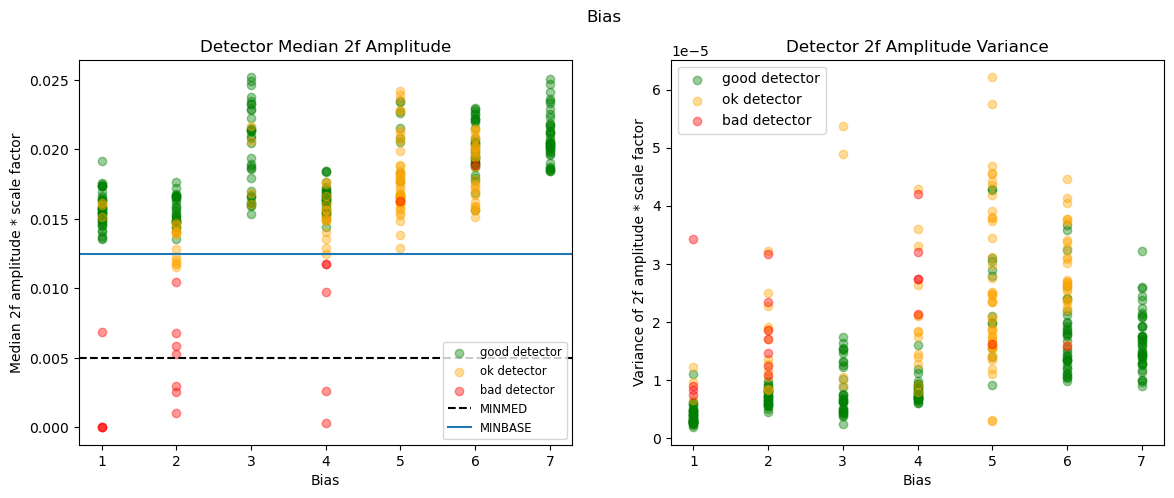

In [76]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['bias'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Bias")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower right', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['bias'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Bias")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Bias")

Text(0.5, 0.98, 'Bias')

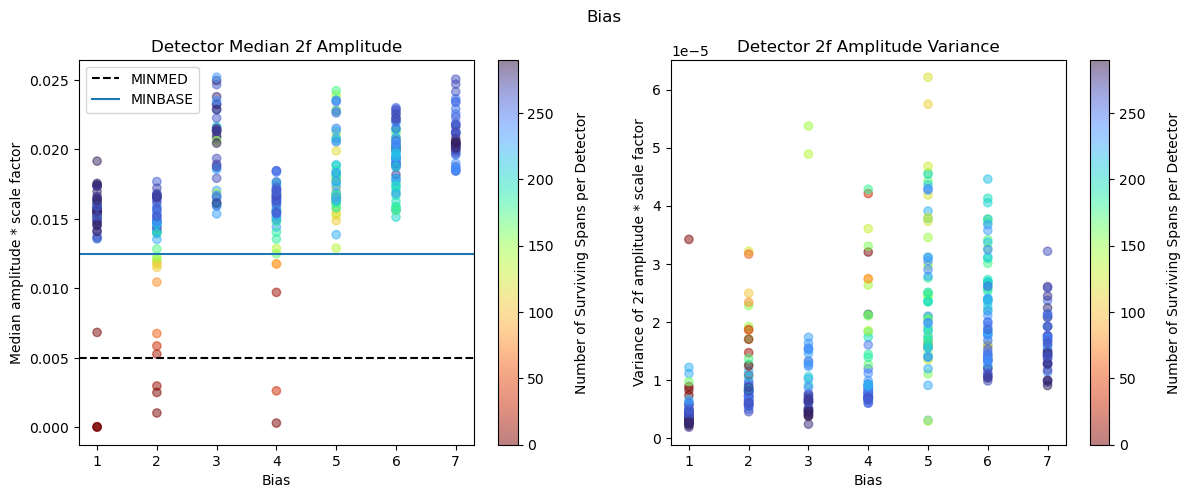

In [77]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['bias'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Bias")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['bias'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Bias")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Bias")

## WAFER

Text(0.5, 0.98, 'Wafer')

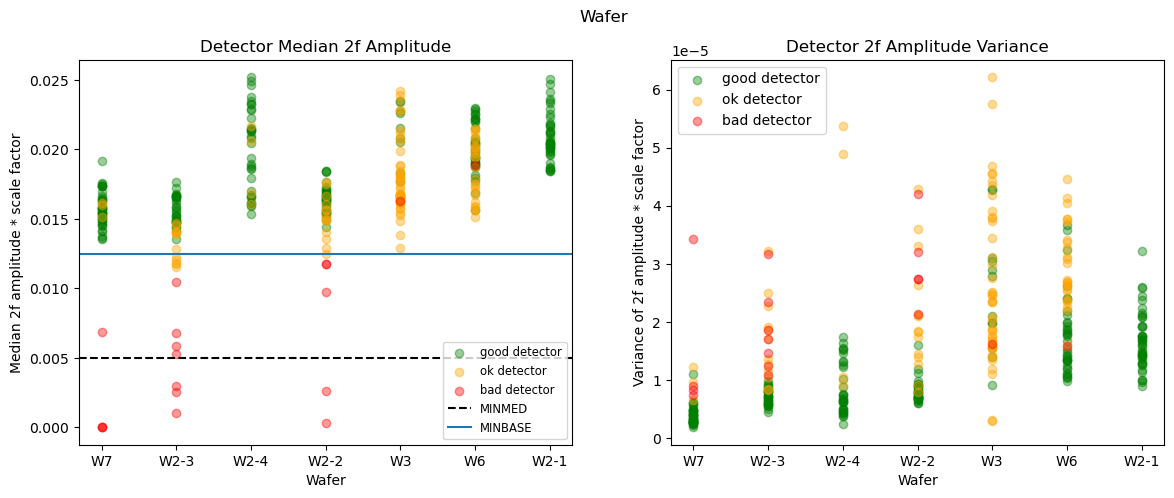

In [78]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['wafer'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Wafer")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower right', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['wafer'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Wafer")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Wafer")

Text(0.5, 0.98, 'Wafer')

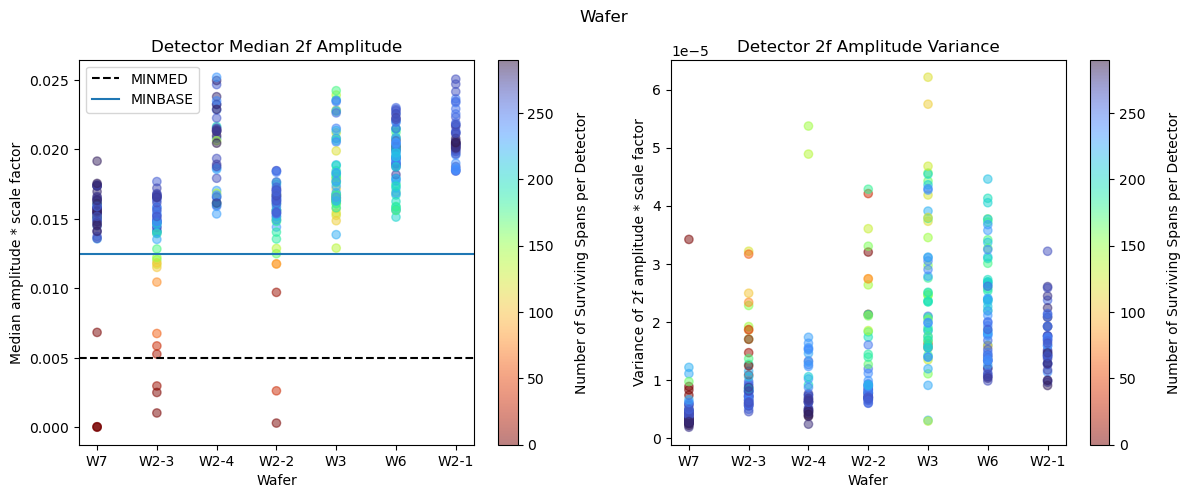

In [79]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['wafer'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Wafer")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['wafer'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Wafer")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Wafer")

## ROW

Text(0.5, 0.98, 'Row')

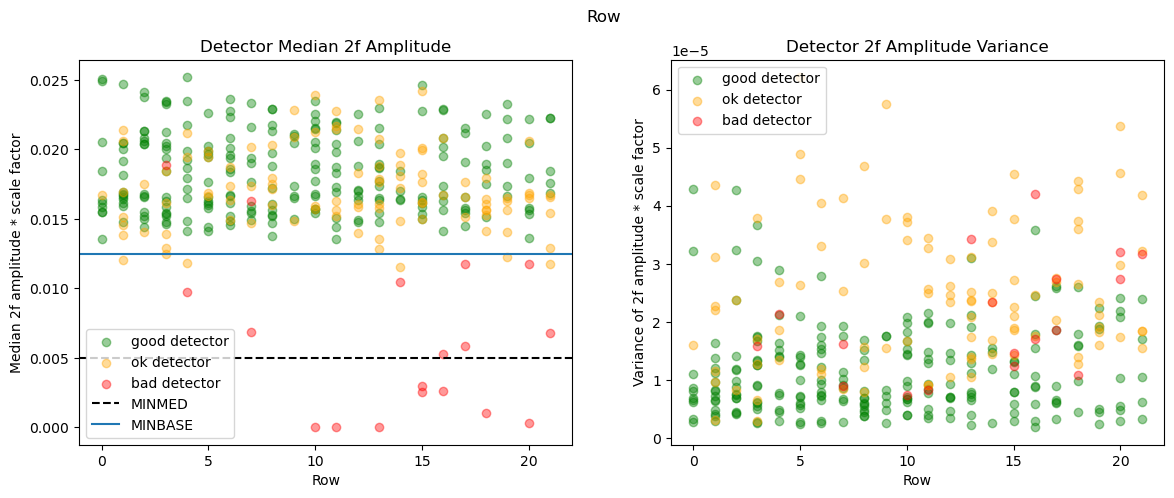

In [80]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['row'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Row")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['row'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Row")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Row")

Text(0.5, 0.98, 'Row')

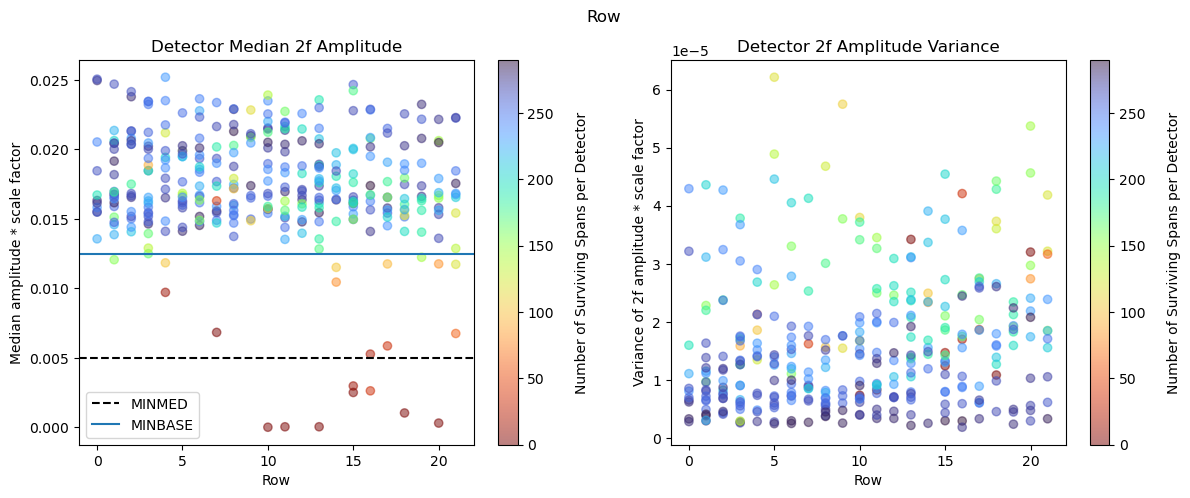

In [81]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['row'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Row")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['row'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Row")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Row")

## COLUMN
Column #23 has no good detectors

Text(0.5, 0.98, 'Column')

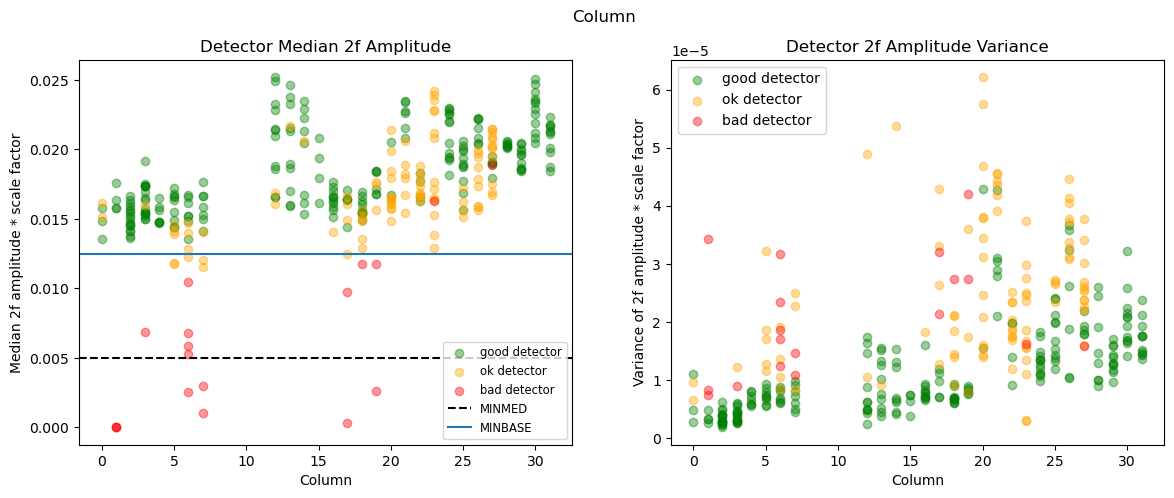

In [82]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['col'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Column")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower right', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['col'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Column")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Column")

Text(0.5, 0.98, 'Column')

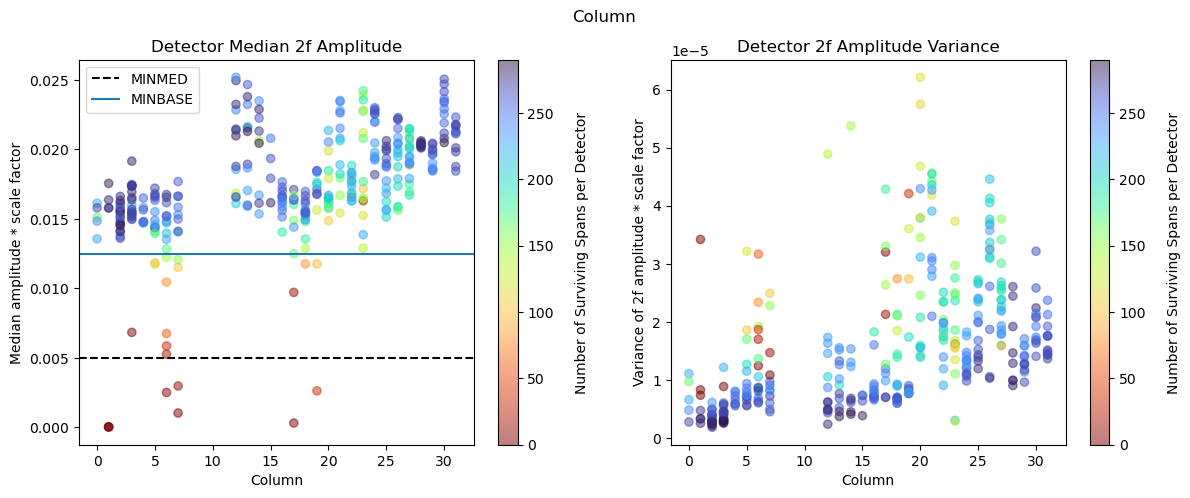

In [83]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['col'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Column")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['col'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Column")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Column")

## Tc

Text(0.5, 0.98, 'Tc')

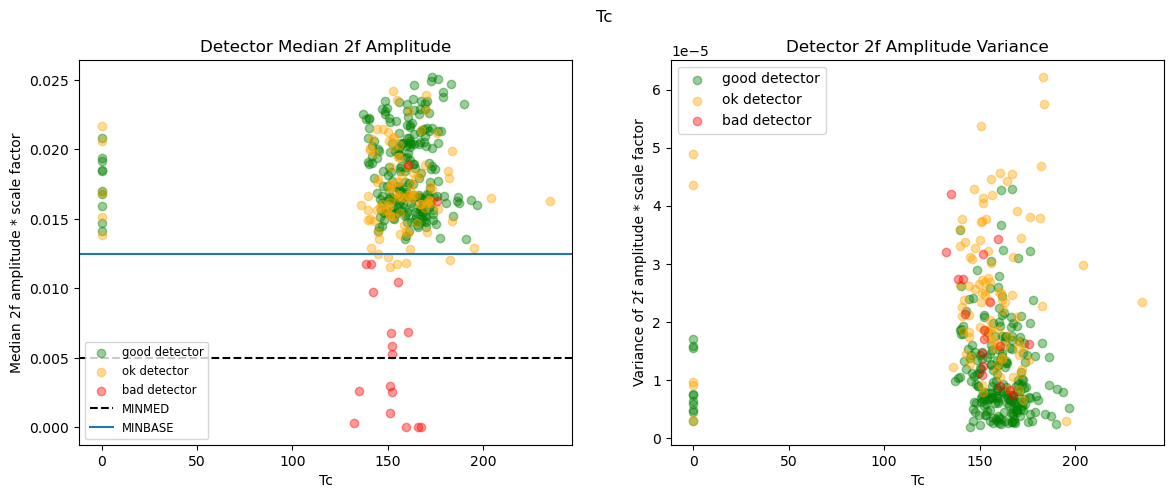

In [138]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['Tc'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Tc")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['Tc'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Tc")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Tc")

Text(0.5, 0.98, 'Tc')

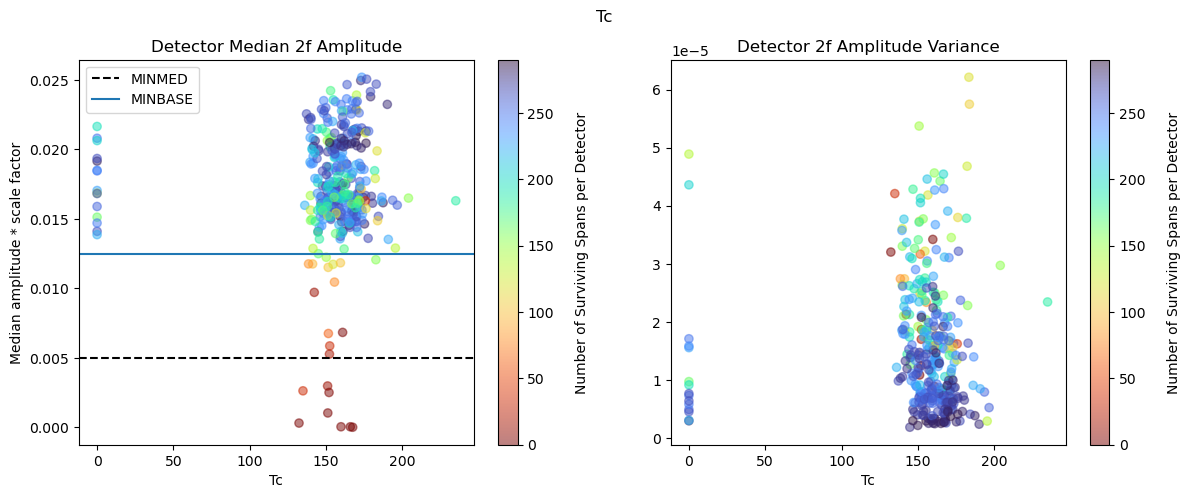

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['Tc'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Tc")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['Tc'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Tc")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Tc")

Text(0.5, 0.98, 'Tc (zoomed in)')

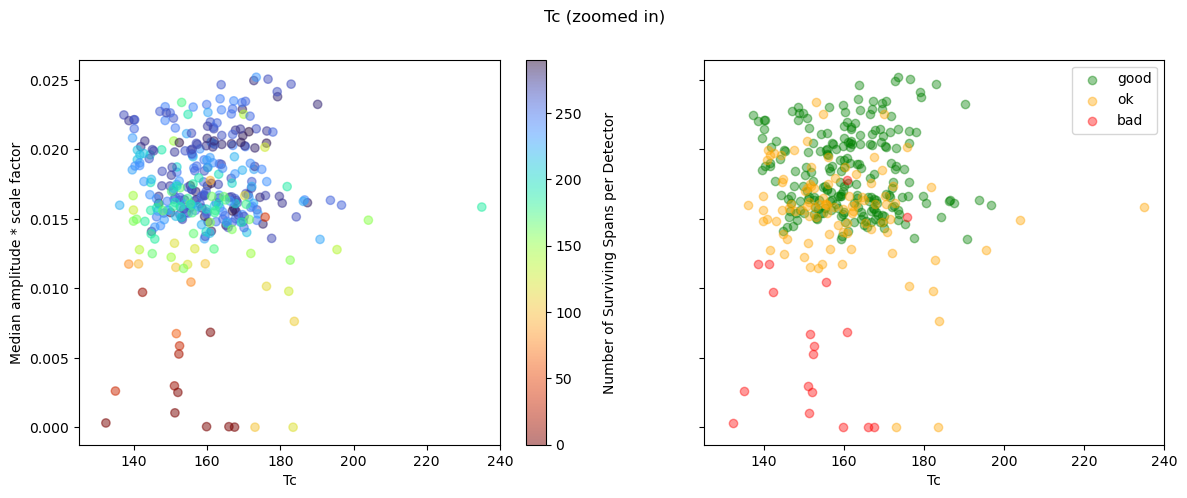

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [8, 7]}
)

sc = ax1.scatter(df['Tc'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Tc")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.set_xlim(125,240)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['Tc'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=group,
        alpha=0.4
    )
ax2.set_xlabel("Tc")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_xlim(125,240)
ax2.legend()
fig.suptitle("Tc (zoomed in)")

## KAPPA

Text(0.5, 0.98, 'Kappa')

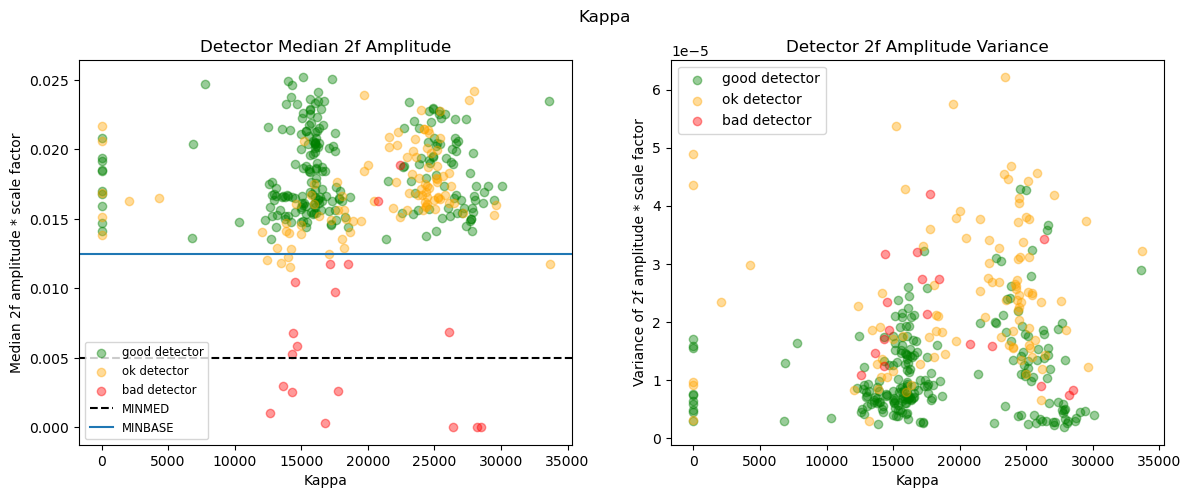

In [139]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['kappa'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Kappa")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['kappa'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Kappa")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Kappa")

Text(0.5, 0.98, 'Kappa')

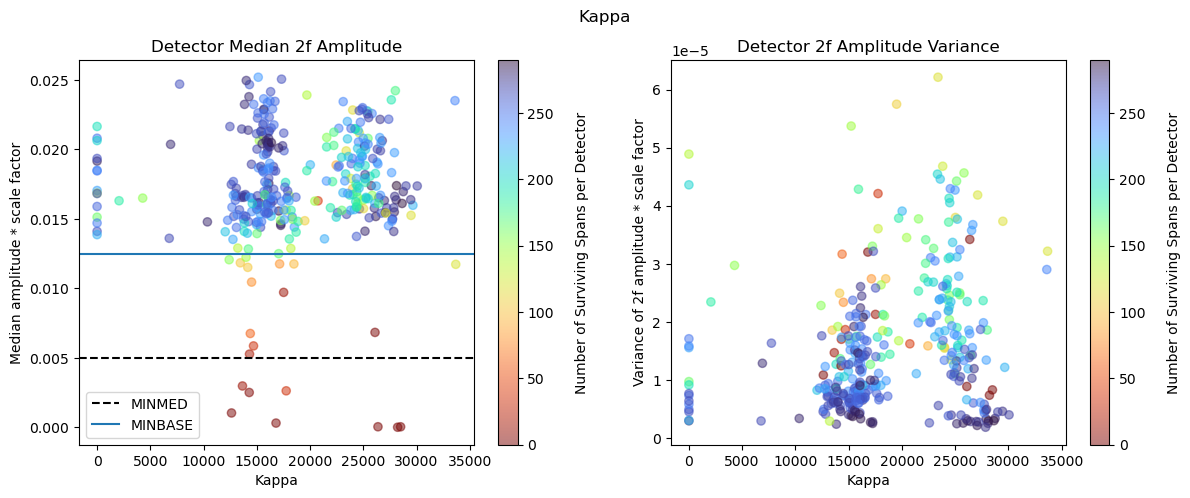

In [86]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['kappa'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Kappa")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['kappa'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Kappa")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Kappa")

## Rn

Text(0.5, 0.98, 'Rn')

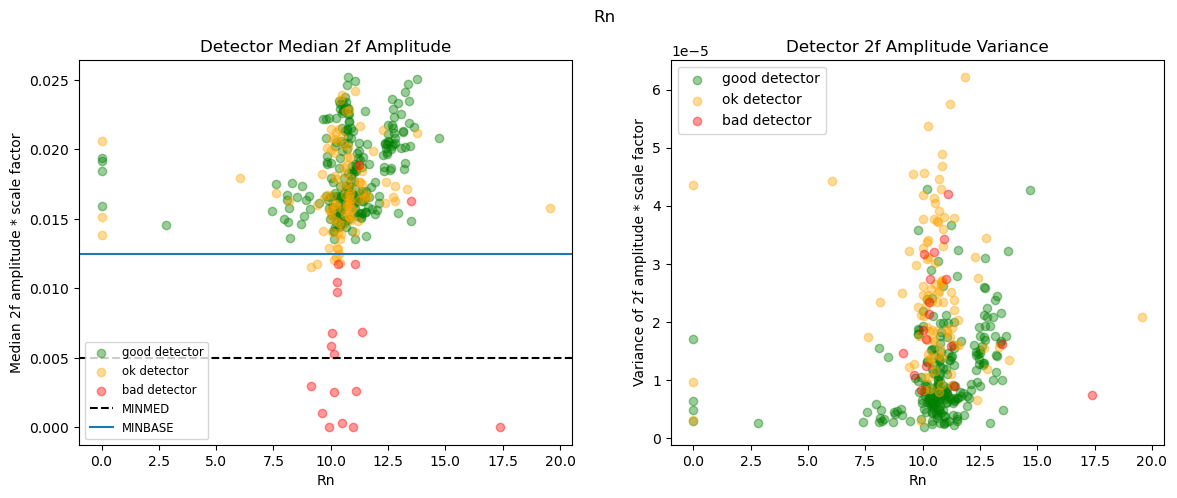

In [87]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['Rn'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Rn")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['Rn'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Rn")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Rn")

Text(0.5, 0.98, 'Rn')

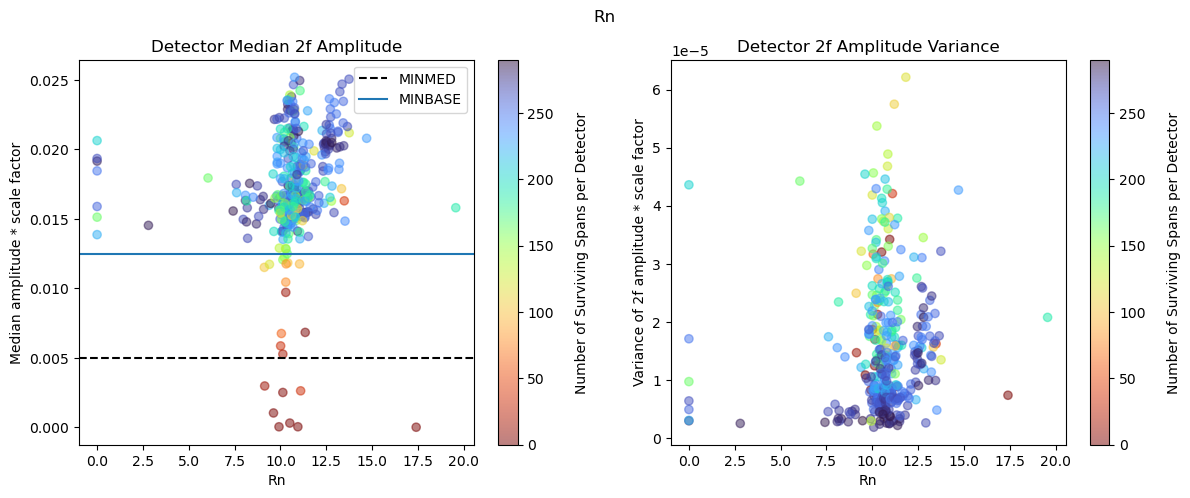

In [88]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['Rn'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Rn")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['Rn'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Rn")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Rn")

## EFF_REL

Text(0.5, 0.98, 'eff_rel')

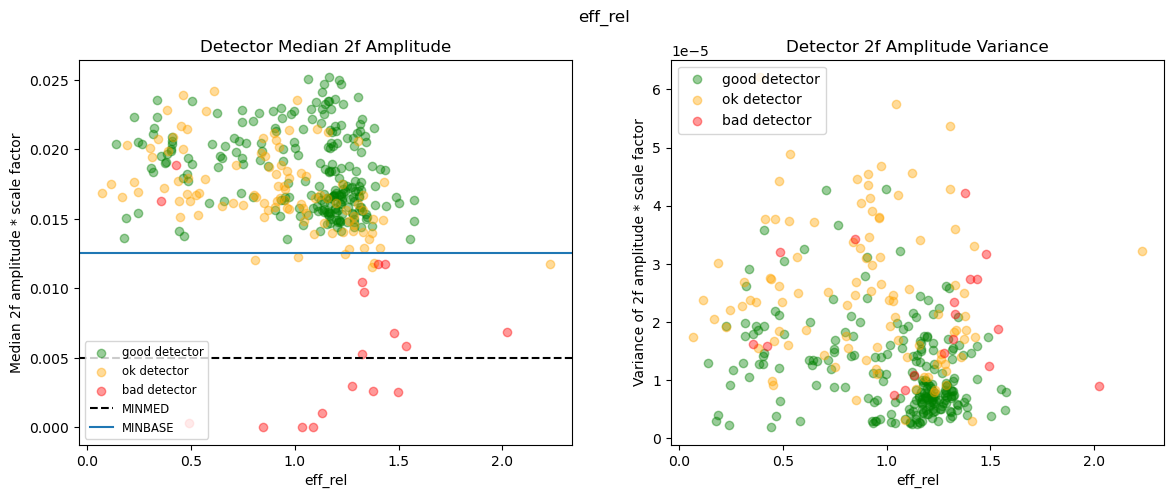

In [89]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['eff_rel'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("eff_rel")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['eff_rel'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("eff_rel")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("eff_rel")

Text(0.5, 0.98, 'eff_rel')

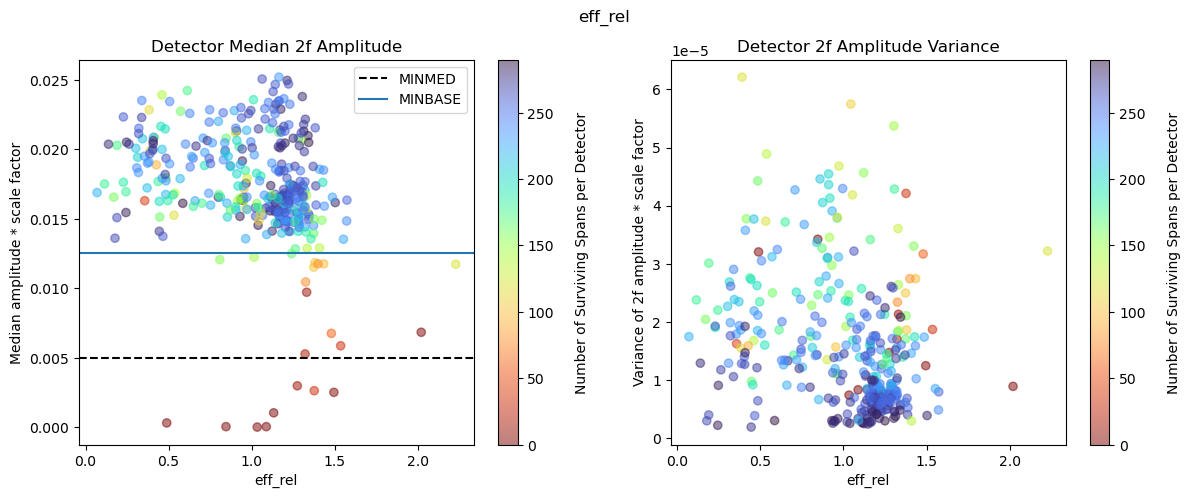

In [90]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['eff_rel'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("eff_rel")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")

sc2 = ax2.scatter(df['eff_rel'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("eff_rel")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("eff_rel")

## AZIMUTHAL OFFSET
Bad detectors are mostly at azimuthal offsets close to 0

Text(0.5, 0.98, 'Azimuthal Offset')

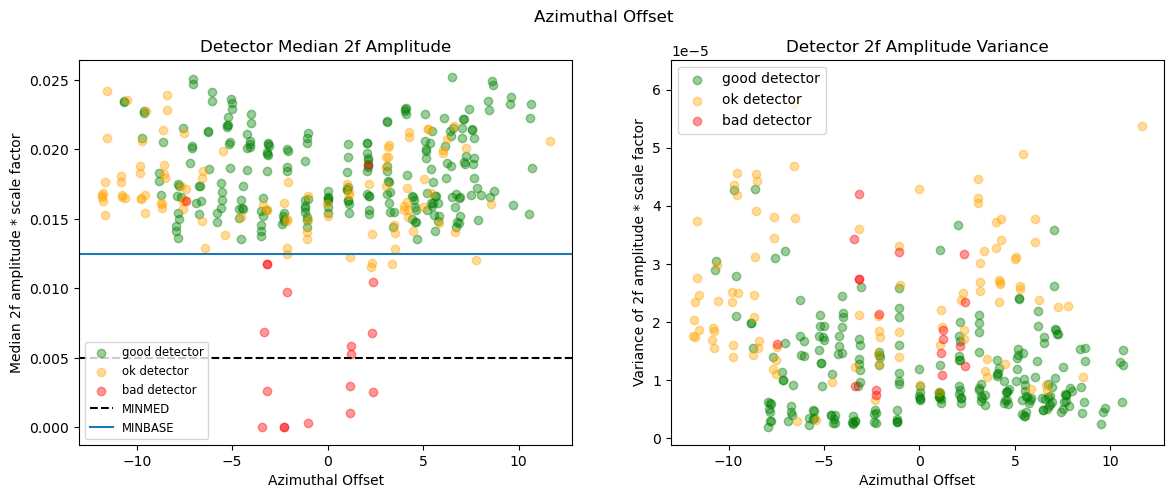

In [140]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['az_off'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Azimuthal Offset")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['az_off'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Azimuthal Offset")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Azimuthal Offset")

Text(0.5, 0.98, 'Azimuthal Offset')

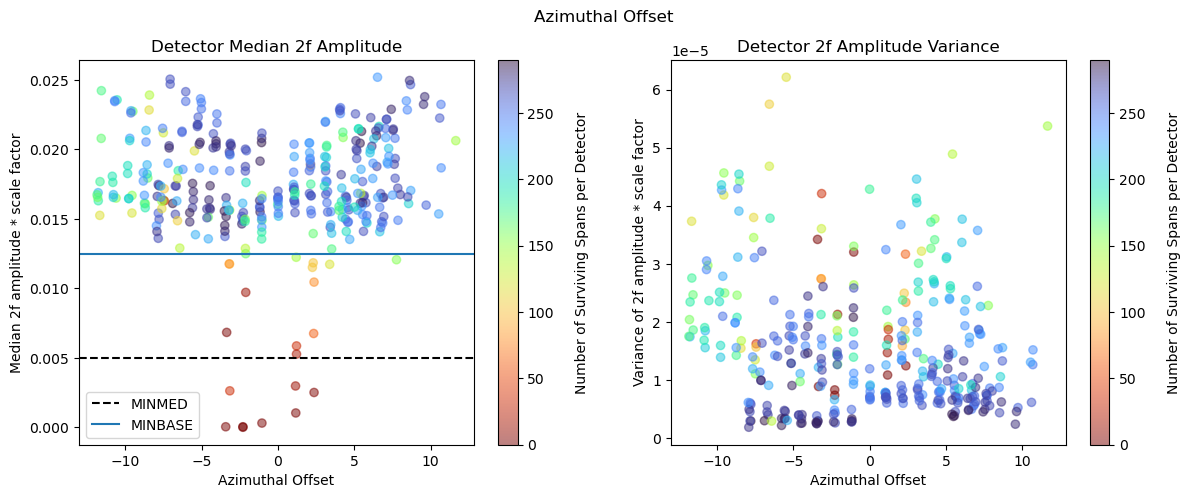

In [141]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['az_off'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Azimuthal Offset")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")
ax1.set_ylabel("Median 2f amplitude * scale factor")

sc2 = ax2.scatter(df['az_off'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Azimuthal Offset")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Azimuthal Offset")

## ELEVATION OFFSET

Text(0.5, 0.98, 'Elevation Offset')

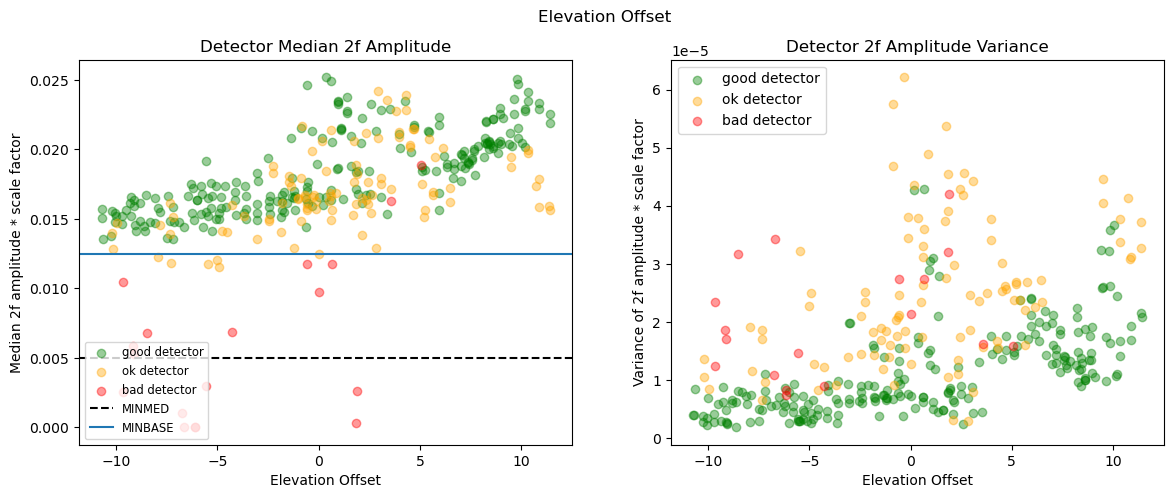

In [142]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['el_off'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Elevation Offset")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['el_off'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Elevation Offset")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Elevation Offset")

Text(0.5, 0.98, 'Elevation Offset')

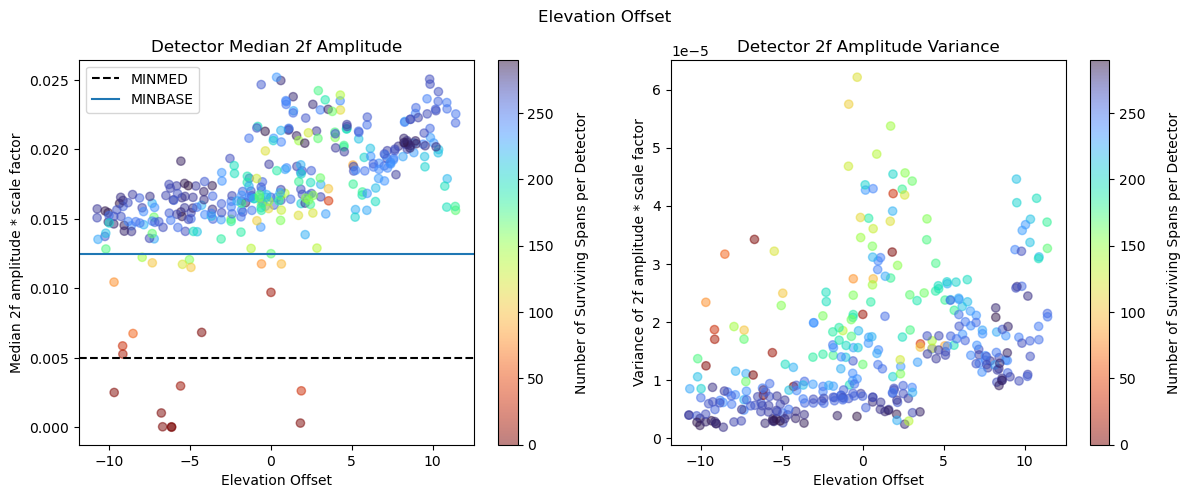

In [143]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['el_off'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Elevation Offset")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")
ax1.set_ylabel("Median 2f amplitude * scale factor")

sc2 = ax2.scatter(df['el_off'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Elevation Offset")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Elevation Offset")

## MEDIAN PWV

Text(0.5, 0.98, 'Median PWV')

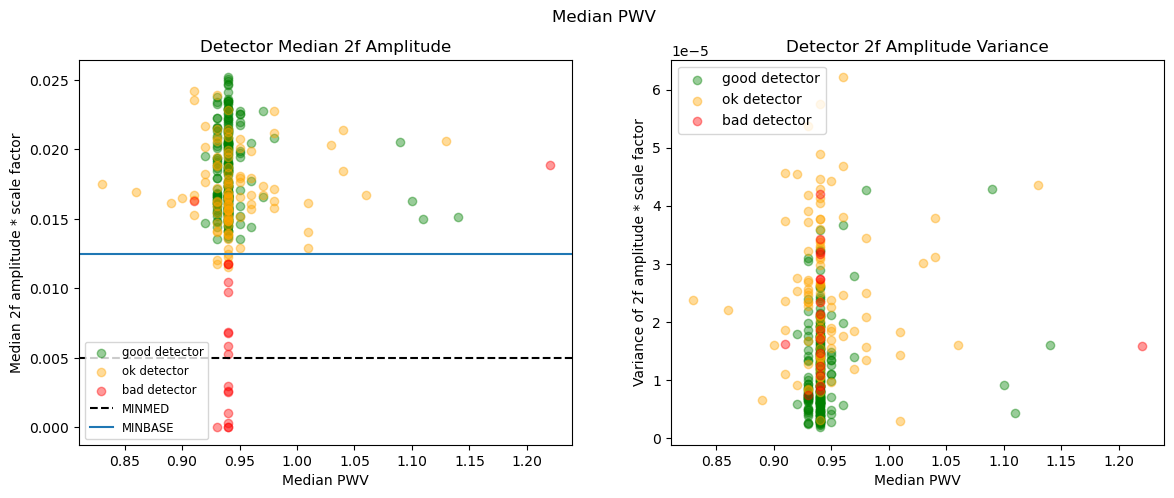

In [96]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

color_map = {
    "good": "green",
    "ok": "orange",
    "bad": "red"
}

colors = df["performance"].map(color_map)

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax1.scatter(
        df['median_pwv'][mask],
        df['median_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax1.set_xlabel("Median PWV")
ax1.set_ylabel("Median 2f amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='lower left', fontsize='small')
ax1.set_title("Detector Median 2f Amplitude")

for group, color in [("good", "green"), ("ok", "orange"), ("bad", "red")]:
    mask = df["performance"] == group
    ax2.scatter(
        df['median_pwv'][mask],
        df['var_amplitude'][mask],
        color=color,
        label=f"{group} detector",
        alpha=0.4
    )
ax2.set_xlabel("Median PWV")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
#ax2.axhline(1e-6, label='MAXVAR', color='black', ls='--')
ax2.legend(loc='upper left')
ax2.set_title("Detector 2f Amplitude Variance")

fig.suptitle("Median PWV")

Text(0.5, 0.98, 'Median PWV')

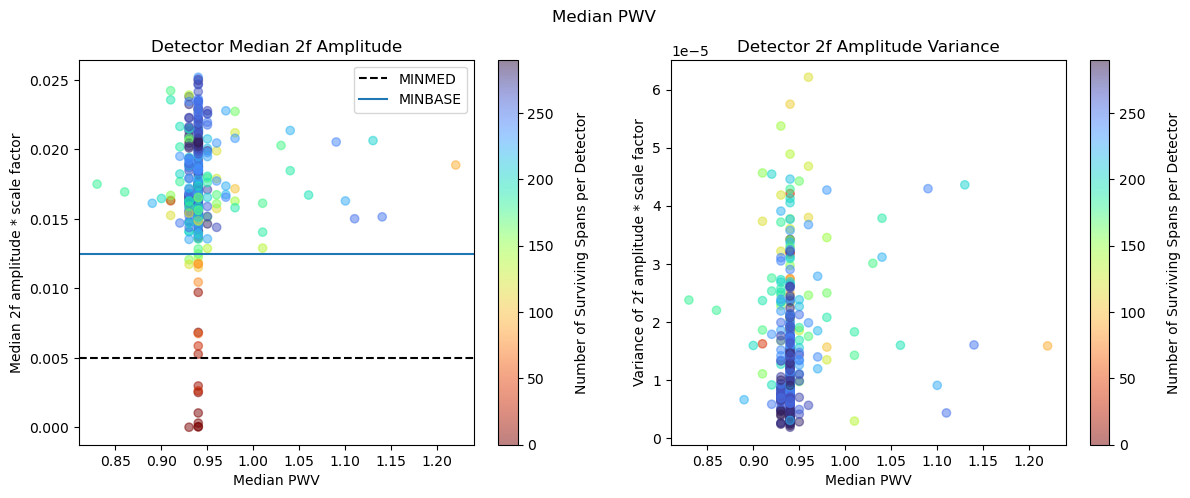

In [95]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    #sharey=True,
    gridspec_kw={"width_ratios": [7, 7]}
)

sc = ax1.scatter(df['median_pwv'], df['median_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax1)

cbar.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)
ax1.set_xlabel("Median PWV")
ax1.set_ylabel("Median amplitude * scale factor")
ax1.axhline(0.005, label='MINMED', color='black', ls='--')
ax1.axhline(0.0125, label='MINBASE')
ax1.legend(loc='best')
ax1.set_title("Detector Median 2f Amplitude")
ax1.set_ylabel("Median 2f amplitude * scale factor")

sc2 = ax2.scatter(df['median_pwv'], df['var_amplitude'], c=df['surviving_spans'], cmap='turbo_r', alpha=0.5)
cbar2 = fig.colorbar(sc2, ax=ax2)

cbar2.set_label('Number of Surviving Spans per Detector', rotation=90, labelpad=15)

ax2.set_xlabel("Median PWV")
ax2.set_ylabel("Variance of 2f amplitude * scale factor")
ax2.set_title("Detector 2f Amplitude Variance")
fig.suptitle("Median PWV")